In [2]:
# ============================================================
# 03_brand_analysiss.ipynb
# Brand Analysis - Core drop-off visualisation
# ============================================================

# Imports and connection
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from db_connection import get_engine

engine = get_engine()
print("Connected.")

Connected.


In [3]:
# Load brand funnel data
query = """
WITH brand_funnel AS (
    SELECT
        brand,
        COUNT(DISTINCT CASE WHEN event_type = 'view'
              THEN user_id END)     AS users_viewed,
        COUNT(DISTINCT CASE WHEN event_type = 'cart'
              THEN user_id END)     AS users_carted,
        COUNT(DISTINCT CASE WHEN event_type = 'purchase'
              THEN user_id END)     AS users_purchased
    FROM events_clean
    WHERE brand IS NOT NULL
    GROUP BY brand
    HAVING COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_id END) >= 1000
)
SELECT
    brand,
    users_viewed,
    users_carted,
    users_purchased,
    ROUND(users_carted    * 100.0 / NULLIF(users_viewed, 0), 2) AS view_to_cart_rate,
    ROUND(users_purchased * 100.0 / NULLIF(users_carted, 0), 2) AS cart_to_purchase_rate,
    ROUND(users_purchased * 100.0 / NULLIF(users_viewed, 0), 2) AS overall_conversion_rate
FROM brand_funnel
ORDER BY overall_conversion_rate DESC;
"""
brand_df = pd.read_sql(query, engine)
print(f"Brands analysed: {len(brand_df)}")
print(brand_df.head())

Brands analysed: 84
        brand  users_viewed  users_carted  users_purchased  view_to_cart_rate  \
0    sapphire          3636          1074              578              29.54   
1         msi          7716          2202             1125              28.54   
2    nv-print          1860           312              225              16.77   
3    gigabyte          9425          2353             1128              24.97   
4  powercolor          1732           380              187              21.94   

   cart_to_purchase_rate  overall_conversion_rate  
0                  53.82                    15.90  
1                  51.09                    14.58  
2                  72.12                    12.10  
3                  47.94                    11.97  
4                  49.21                    10.80  


In [4]:
# Top 10 and bottom 10 brands
top10    = brand_df.head(10).copy()
bottom10 = brand_df.tail(10).copy()

print("Top 10 converting brands:")
print(top10[['brand', 'users_viewed', 'overall_conversion_rate']])
print("\nBottom 10 converting brands:")
print(bottom10[['brand', 'users_viewed', 'overall_conversion_rate']])

Top 10 converting brands:
        brand  users_viewed  overall_conversion_rate
0    sapphire          3636                    15.90
1         msi          7716                    14.58
2    nv-print          1860                    12.10
3    gigabyte          9425                    11.97
4  powercolor          1732                    10.80
5      pantum          1454                    10.73
6     brother          1130                     9.73
7       epson          3387                     8.06
8       topon          3934                     7.96
9       fubag          1445                     7.96

Bottom 10 converting brands:
       brand  users_viewed  overall_conversion_rate
74      sony          4434                     1.76
75    lenovo          1023                     1.66
76   patriot          1806                     1.55
77   philips          3584                     1.42
78  deepcool          2500                     1.28
79    orient          1585                     1.

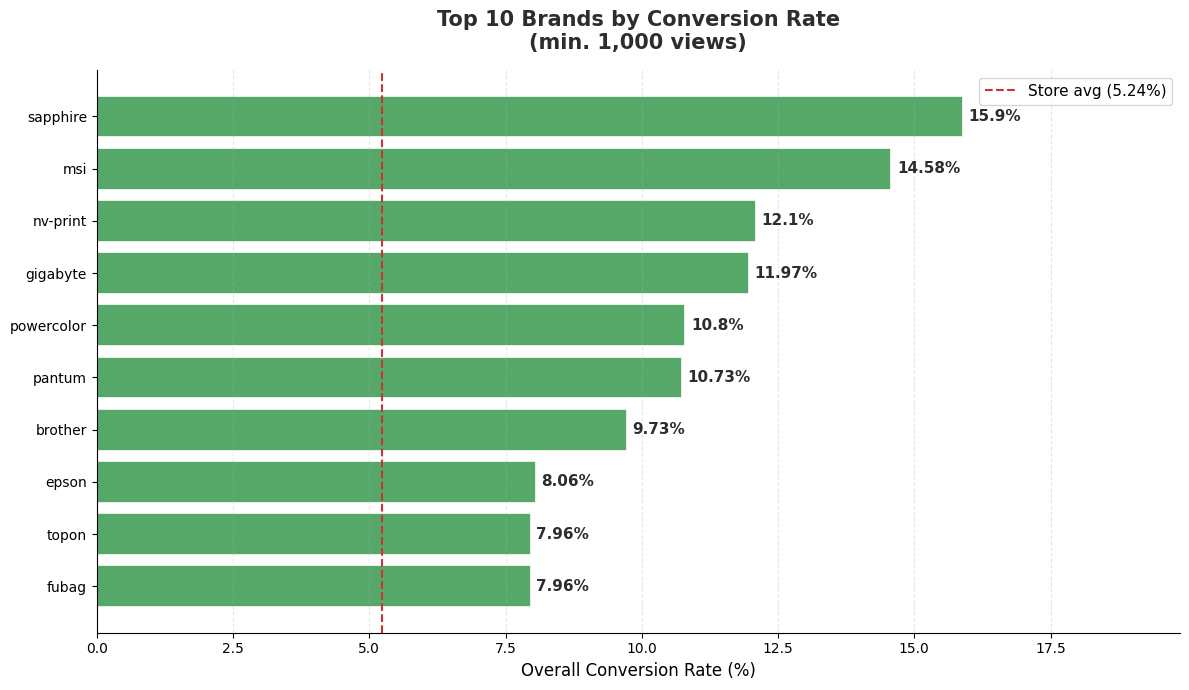

Saved.


In [5]:
# Top 10 best converting brands chart
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top10['brand'][::-1],
    top10['overall_conversion_rate'][::-1],
    color='#55A868', edgecolor='white', linewidth=1.2
)

# Store average reference line
ax.axvline(x=5.24, color='#cc3333', linestyle='--',
           linewidth=1.5, label='Store avg (5.24%)')

# Value labels
for bar, val in zip(bars, top10['overall_conversion_rate'][::-1]):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{val}%',
        va='center', fontsize=11, fontweight='bold', color='#2d2d2d'
    )

ax.set_title(
    'Top 10 Brands by Conversion Rate\n(min. 1,000 views)',
    fontsize=15, fontweight='bold', pad=15, color='#2d2d2d'
)
ax.set_xlabel('Overall Conversion Rate (%)', fontsize=12)
ax.set_xlim(0, max(top10['overall_conversion_rate']) * 1.25)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/03_top10_brands.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

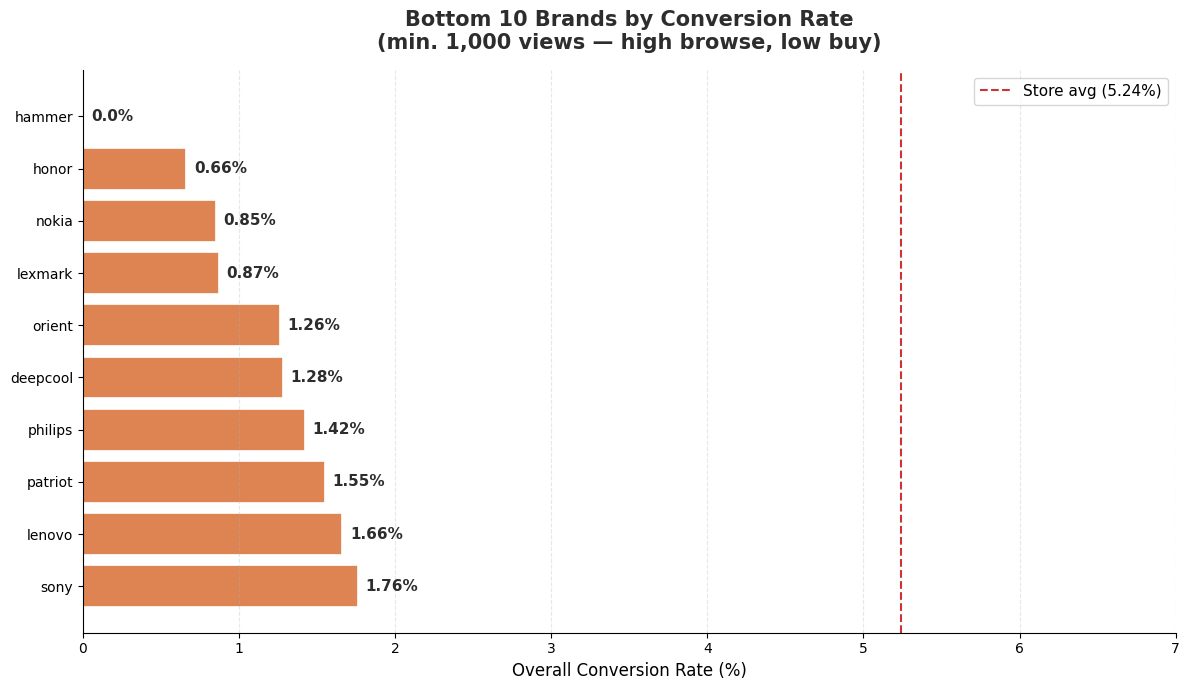

Saved.


In [6]:
# Bottom 10 worst converting brands chart
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    bottom10['brand'],
    bottom10['overall_conversion_rate'],
    color='#DD8452', edgecolor='white', linewidth=1.2
)

# Store average reference line
ax.axvline(x=5.24, color='#cc3333', linestyle='--',
           linewidth=1.5, label='Store avg (5.24%)')

for bar, val in zip(bars, bottom10['overall_conversion_rate']):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{val}%',
        va='center', fontsize=11, fontweight='bold', color='#2d2d2d'
    )

ax.set_title(
    'Bottom 10 Brands by Conversion Rate\n(min. 1,000 views — high browse, low buy)',
    fontsize=15, fontweight='bold', pad=15, color='#2d2d2d'
)
ax.set_xlabel('Overall Conversion Rate (%)', fontsize=12)
ax.set_xlim(0, 7)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/03_bottom10_brands.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

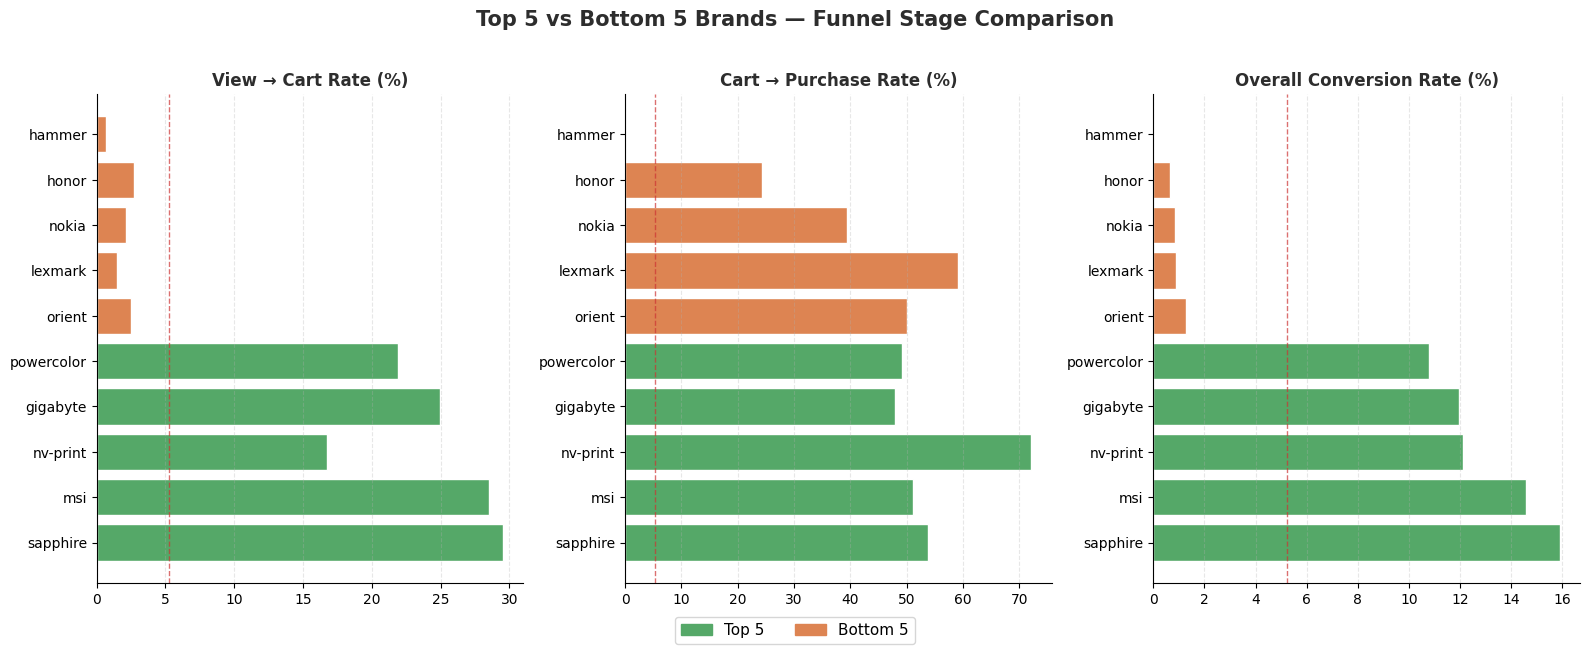

Saved.


In [7]:
# Brand funnel comparison — top 5 vs bottom 5
# Three stage rates side by side
top5    = brand_df.head(5).copy()
bottom5 = brand_df.tail(5).copy()
compare = pd.concat([top5, bottom5], ignore_index=True)
compare['group'] = ['Top 5'] * 5 + ['Bottom 5'] * 5

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics = ['view_to_cart_rate', 'cart_to_purchase_rate', 'overall_conversion_rate']
titles  = ['View → Cart Rate (%)', 'Cart → Purchase Rate (%)', 'Overall Conversion Rate (%)']
colors  = {'Top 5': '#55A868', 'Bottom 5': '#DD8452'}

for ax, metric, title in zip(axes, metrics, titles):
    for i, (_, row) in enumerate(compare.iterrows()):
        color = colors[row['group']]
        ax.barh(row['brand'], row[metric], color=color, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold', color='#2d2d2d')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.axvline(x=5.24, color='#cc3333', linestyle='--',
               linewidth=1, alpha=0.7)

top_patch    = mpatches.Patch(color='#55A868', label='Top 5')
bottom_patch = mpatches.Patch(color='#DD8452', label='Bottom 5')
fig.legend(handles=[top_patch, bottom_patch],
           loc='lower center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, -0.05))

fig.suptitle(
    'Top 5 vs Bottom 5 Brands — Funnel Stage Comparison',
    fontsize=15, fontweight='bold', color='#2d2d2d', y=1.02
)
plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/03_brand_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

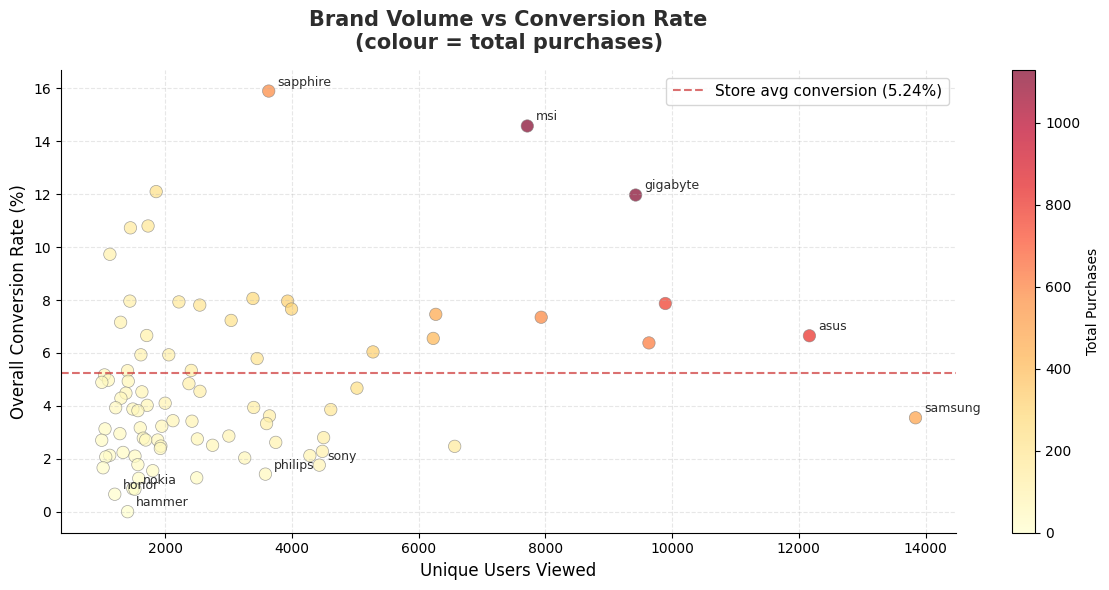

Saved.


In [8]:
# Brand volume vs conversion scatter
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(
    brand_df['users_viewed'],
    brand_df['overall_conversion_rate'],
    c=brand_df['users_purchased'],
    cmap='YlOrRd',
    s=80, alpha=0.7, edgecolors='gray', linewidth=0.5
)

# Label notable brands
notable = ['sapphire', 'msi', 'gigabyte', 'asus', 'samsung',
           'hammer', 'sony', 'philips', 'honor', 'nokia']
for _, row in brand_df[brand_df['brand'].isin(notable)].iterrows():
    ax.annotate(
        row['brand'],
        (row['users_viewed'], row['overall_conversion_rate']),
        textcoords='offset points', xytext=(6, 4),
        fontsize=9, color='#2d2d2d'
    )

# Store average lines
ax.axhline(y=5.24, color='#cc3333', linestyle='--',
           linewidth=1.5, alpha=0.7, label='Store avg conversion (5.24%)')

plt.colorbar(scatter, label='Total Purchases')
ax.set_title(
    'Brand Volume vs Conversion Rate\n(colour = total purchases)',
    fontsize=15, fontweight='bold', pad=15, color='#2d2d2d'
)
ax.set_xlabel('Unique Users Viewed', fontsize=12)
ax.set_ylabel('Overall Conversion Rate (%)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/03_brand_scatter.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

#### Brand Performance Insights:

- Top Brands generate highest revenue due to strong conversion and/or pricing.
- Some brands have high views but low conversion → potential UX/pricing issue.
- Brands with high conversion but low traffic → opportunity to promote.

#### Business Recommendations:

- Promote high-conversion brands with ads
- Improve product pages for low-conversion brands
- Analyze pricing strategy for underperforming brands